<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Wavefunctions_%2B_Probability_Densities_for_an_Electron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2025)

Open Access (CC-BY-4.0)

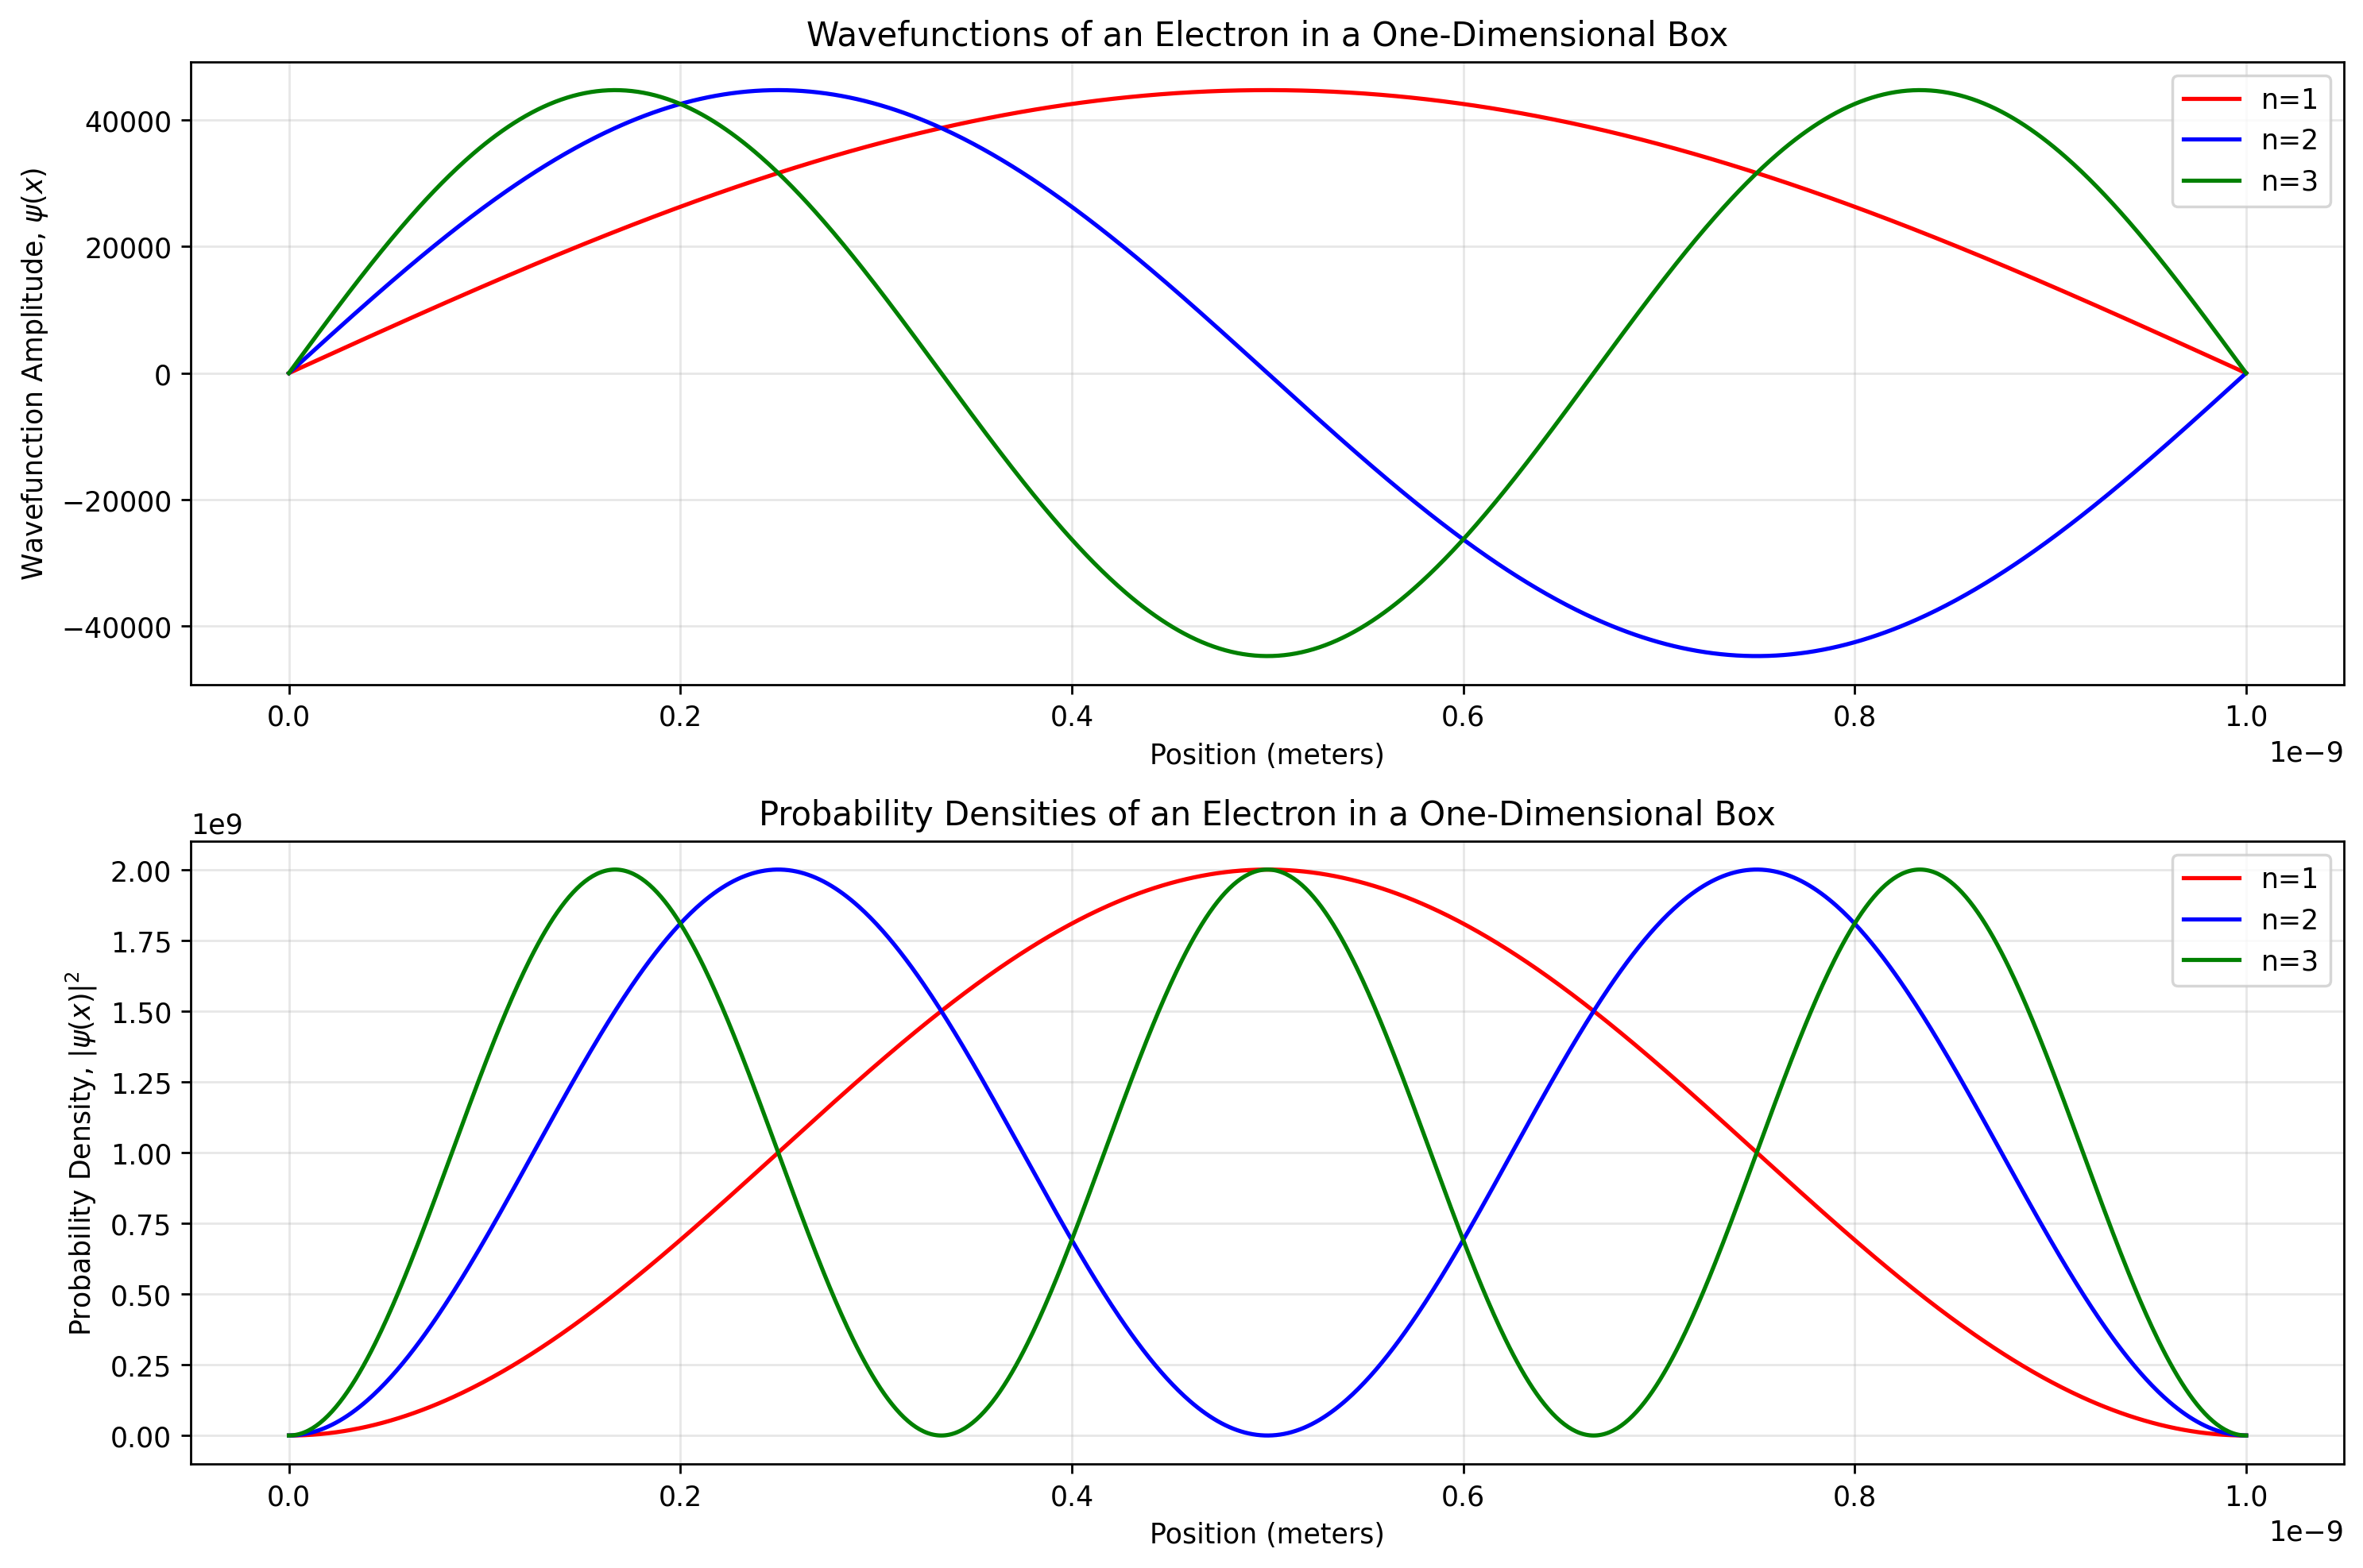

In [4]:
# Installation command for required packages
# uv pip install numpy matplotlib

"""
Calculate and visualize the quantum mechanical properties of a particle in a box.

This module computes the wavefunctions and probability densities for an electron
confined to a one-dimensional potential well.
"""

import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# Control Knobs (Simulation and Visualization Parameters)
# ==============================================================================
BOX_LENGTH_NM = 1.0        # Length of the one-dimensional box in nanometers
MAX_QUANTUM_NUMBER = 3     # Highest energy state to compute (n=1, 2, ..., max)
NUM_SPATIAL_POINTS = 1000  # Resolution of the spatial grid for plotting
FIGURE_DPI = 250           # Resolution of the output figure (rendered in-line)

# Dictionary mapping principal quantum numbers to specific visualization colors
STATE_COLORS = {
    1: 'red',
    2: 'blue',
    3: 'green'
}

# Apply the user-defined DPI setting globally for all Matplotlib figures
plt.rcParams['figure.dpi'] = FIGURE_DPI

# Fundamental Physical Constants
HBAR = 1.0545718e-34            # Reduced Planck constant (Joules * seconds)
ELECTRON_MASS = 9.10938356e-31  # Mass of an electron (kilograms)

def calculate_wavefunction(
    position: np.ndarray,
    quantum_number: int,
    box_length: float
) -> np.ndarray:
    """
    Calculate the spatial wavefunction for a given quantum state.

    The wavefunction describes the probability amplitude of finding the particle
    at a specific position within the boundaries of the well.

    Parameters
    ----------
    position : np.ndarray
        The spatial coordinates along the length of the box (meters).
    quantum_number : int
        The principal quantum number determining the energy level (n = 1, 2, ...).
    box_length : float
        The total geometric length of the one-dimensional box (meters).

    Returns
    -------
    np.ndarray
        The computed continuous wavefunction values across the given positions.
    """
    normalization_constant = np.sqrt(2.0 / box_length)
    wave_vector = (quantum_number * np.pi) / box_length

    return normalization_constant * np.sin(wave_vector * position)

def calculate_energy(
    quantum_number: int,
    box_length: float,
    mass: float
) -> float:
    """
    Compute the quantized energy level for a specific quantum state.

    Parameters
    ----------
    quantum_number : int
        The principal quantum number (n = 1, 2, ...).
    box_length : float
        The total geometric length of the one-dimensional box (meters).
    mass : float
        The invariant mass of the confined particle (kilograms).

    Returns
    -------
    float
        The discrete energy of the specified quantum state (Joules).
    """
    numerator = (quantum_number**2) * (np.pi**2) * (HBAR**2)
    denominator = 2.0 * mass * (box_length**2)

    return numerator / denominator

def plot_particle_in_box() -> None:
    """
    Generate and render the wavefunctions and associated probability densities.

    This routine iterates through the defined principal quantum numbers, computes
    the corresponding theoretical spatial values, and renders a two-panel
    visualization displaying the wavefunction amplitude alongside its squared
    modulus (probability density) using state-specific color mapping.
    """
    # Convert the dimensional length from nanometers to meters for SI calculations
    box_length_m = BOX_LENGTH_NM * 1e-9

    # Generate the linear spatial grid
    positions = np.linspace(0, box_length_m, NUM_SPATIAL_POINTS)
    quantum_numbers = range(1, MAX_QUANTUM_NUMBER + 1)

    # Initialize the figure canvas with two vertically stacked subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    for n in quantum_numbers:
        psi_values = calculate_wavefunction(positions, n, box_length_m)
        probability_density = np.abs(psi_values)**2

        # Retrieve the assigned color from the dictionary (defaulting to black)
        plot_color = STATE_COLORS.get(n, 'black')

        # Map the primary wavefunction onto the first axis
        ax1.plot(positions, psi_values, label=f'n={n}', color=plot_color)

        # Map the derived probability density onto the second axis
        ax2.plot(positions, probability_density, label=f'n={n}', color=plot_color)

   # Configure the structural elements of the wavefunction subplot
    ax1.set_title('Wavefunctions of an Electron in a One-Dimensional Box')
    ax1.set_xlabel('Position (meters)')
    ax1.set_ylabel(r'Wavefunction Amplitude, $\psi(x)$')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Configure the structural elements of the probability density subplot
    ax2.set_title('Probability Densities of an Electron in a One-Dimensional Box')
    ax2.set_xlabel('Position (meters)')
    ax2.set_ylabel(r'Probability Density, $|\psi(x)|^2$')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Ensure the plot components scale gracefully without overlapping
    plt.tight_layout()

    # Render the final visualization strictly within the notebook environment
    plt.show()

if __name__ == '__main__':
    plot_particle_in_box()